In [1]:
import numpy as np
import math
import openflash
from scipy.optimize import curve_fit
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.patches import FancyBboxPatch
print(type(openflash))
print(openflash.__path__)
print(openflash.__file__)

# --- Import core modules from package ---
try:
    from openflash import *
    from openflash.multi_equations import *
    from openflash.multi_constants import g
    print("OpenFLASH modules imported successfully!")
except ImportError as e:
    print(f"Error importing OpenFLASH modules. Error: {e}")

# Set NumPy print options for better readability
np.set_printoptions(threshold=np.inf, linewidth=np.inf, precision=8, suppress=True)
from openflash.multi_constants import rho
from openflash.multi_equations import wavenumber

# Now you can import from the folder structure
# Assuming 'pyplotutilities' is a folder inside 'sea-lab-utils'
import sys
from pathlib import Path
HERE = Path.cwd().resolve()
fig_path_1_str = str((HERE / ".." / "pubs" / "JFM" / "figs" / "alpha-beta-explanation.pdf").resolve())
fig_path_2_str = str((HERE / ".." / "pubs" / "JFM" / "figs" / "alpha-beta-to-trend.pdf").resolve())
fig_path_3_str = str((HERE / ".." / "pubs" / "JFM" / "figs" / "convergence-fit-assessment.pdf").resolve())

dir_path_1_str = str((HERE / ".." / "dev" / "python" / "convergence-study"))
dir_path_2_str = str((HERE / ".." / "dev" / "python"))
dir_path_3_str = str((HERE / ".." / "sea-lab-utils").resolve())
dir_path_4_str = str((HERE / ".." / "dev" / "python" / "convergence-study" / "prediction"))

data_1_str = str((HERE / ".." / "dev" / "python" / "convergence-study" / "i-region-convergence" / "middle-region" / "data" / "predetermined-4.pkl"))
data_2_str = str((HERE / ".." / "dev" / "python" / "convergence-study" / "prediction" / "data" / "random-three-body-regions.pkl"))
data_3_str = str((HERE / ".." / "dev" / "python" / "convergence-study" / "prediction" / "data" / "random-four-body-regions.pkl"))

for dir_path in [dir_path_1_str, dir_path_2_str, dir_path_3_str, dir_path_4_str]:
  if dir_path not in sys.path:
    sys.path.insert(0, dir_path)

from helpers import ConvergenceProblemI, merge_dicts, open_pkl_file, generate_convergence_data, generate_log_data, color_by_f_value, wrap_m0
from prediction_evaluators import variables_guess_variants, fit_inner_model_weighted, fit_middle_model_weighted, fit_outer_model_weighted, filter_converged, twenty_minimum
from pyplotutilities import colors
from pyplotutilities import fonts
colors.get_colors()
print(colors.purple)
fonts.get_fonts()

<class 'module'>
['/Users/Bimali/Desktop/SEALab/OpenFLASH/package/src/openflash']
/Users/Bimali/Desktop/SEALab/OpenFLASH/package/src/openflash/__init__.py
OpenFLASH modules imported successfully!


#CC79A7


In [2]:
# Non-slanted CorPower WEC geometry
h = 50.00
omega_val = 1
m0 = wavenumber(omega_val, h)
d = [14.45, 7.13, 2.05]
a = [1.25, 2.725, 4.2]
nmk_max = 200
nmk_big = 150
NMK = [nmk_max for _ in range(4)] # number of coefficients in each region
heaving = [0, 1, 0]

prob1 = ConvergenceProblemI(h, d, a, heaving, NMK, m0, rho)
mk1 = prob1.m_k
info1 = {"h" : h,
        "d" : d,
        "a" : a,
        "region" : 1,
        "m0s" : [m0]}
data1 = merge_dicts(info1, prob1.convergence_study_over_m0s(nmk_big, [m0], [mk1]))

In [3]:
# Plot Settings
l_width = 3 # line width
m_size = 7 # marker size
lab_fs = 11 # x and y label font size
leg_fs = lab_fs  # legend font size
fig_h = 9 # figure height
fig_w = 4 # figure width

def format_ax(ax):
  formatter = ScalarFormatter(useMathText=True)
  formatter.set_scientific(True)
  formatter.set_powerlimits((-1, 1)) 
  ax.yaxis.set_major_formatter(formatter)

In [4]:
def plot_type_1(ax, cf, m0, hydro, alpha, beta, loc):
  if hydro == "am": subscript, ylab = "A", "Added Mass"
  elif hydro == "dp": subscript, ylab = "B", "Damping"
  xs = list(range(1, len(cf[m0][hydro + "s"]) + 1))
  xmin, xmax = 0, len(xs) + 1
  ys = cf[m0][hydro + "s"]
  true_val = cf[m0][hydro]
  ymin, ymax = 0, max(ys + [true_val])*1.1
  ax.scatter(xs, ys, c = colors.blue, s= 5, zorder = 8, label = "Empirical/Computed")
  ax.hlines(true_val, xmin, xmax, color = colors.green, label = rf"True Value ($N^{{i_2}} = 200$)", zorder = 4)
  err_xs_1 = xs + [xmax]
  err_xs_2 = [0] + err_xs_1
  err_fracs = [(x/beta)**(-alpha) for x in ([0.1] + err_xs_1)]
  ax.set_xlim([xmin, xmax])
  ax.set_ylim([ymin, ymax])
  err_lows = [(1 - err_frac) * true_val for err_frac in err_fracs]
  err_highs = [(1 + err_frac) * true_val for err_frac in err_fracs]
  ax.plot(err_xs_2, err_lows, color = colors.orange, linewidth = 1, zorder = 3)
  ax.plot(err_xs_2, err_highs, color = colors.orange, linewidth = 1, zorder = 2)
  ax.fill_between(err_xs_2, err_lows, err_highs,
                  alpha=0.3, color = colors.orange,
                  label=rf"$\epsilon_{subscript} \leq (\frac{{N^{{i2}}}}{{\beta_{subscript}}})^{{-\alpha_{subscript}}}$", zorder = 1)
  ax.set_ylabel(ylab, fontsize = lab_fs)
  ax.legend(loc=loc, fontsize=leg_fs * 1.1, frameon=False)

def plot_type_2(ax, cf, m0, hydro):
  if hydro == "am": subscript = "A"
  elif hydro == "dp": subscript = "B"
  xs = list(range(1, len(cf[m0][hydro + "s"]) + 1))
  xmin, xmax = 0, len(xs) + 1
  xs2 = [0.05] + xs + [xmax]
  true_val = cf[m0][hydro]
  ys = [np.log(np.abs((entry - true_val)/true_val)) for entry in cf[m0][hydro + "s"]]
  ax.scatter(xs, ys, c = colors.blue, label = "Empirical/Computed", s = 8, zorder = 3)
  ymin, ymax = min(ys) - 0.5, max(ys) + 0.5
  popt, pcov = curve_fit(lambda x, a1, a2 : (- a1 * np.log(x/a2)), xs, ys, p0=(1, 1))
  alpha, beta = popt
  ys2 = [- alpha * np.log(x/beta) for x in xs2]
  ax.plot(xs2, ys2, color = colors.orange, label = rf"Fit with $-\alpha_{subscript}\mathrm{{ln}}(\frac{{N^{{i2}}}}{{\beta_{subscript}}})$", zorder = 5)
  ax.hlines(np.log(0.01), xmin, xmax, label = rf"$1\%$ error", linestyle = "--", color = colors.green)
  ax.legend(loc='upper right', fontsize=leg_fs*1.1, frameon=False)
  ax.set_xlim([xmin, xmax])
  ax.set_ylim([ymin, ymax])
  ax.set_ylabel(rf"$\mathrm{{ln}}|\epsilon_{subscript}|$", fontsize = lab_fs)
  return alpha, beta

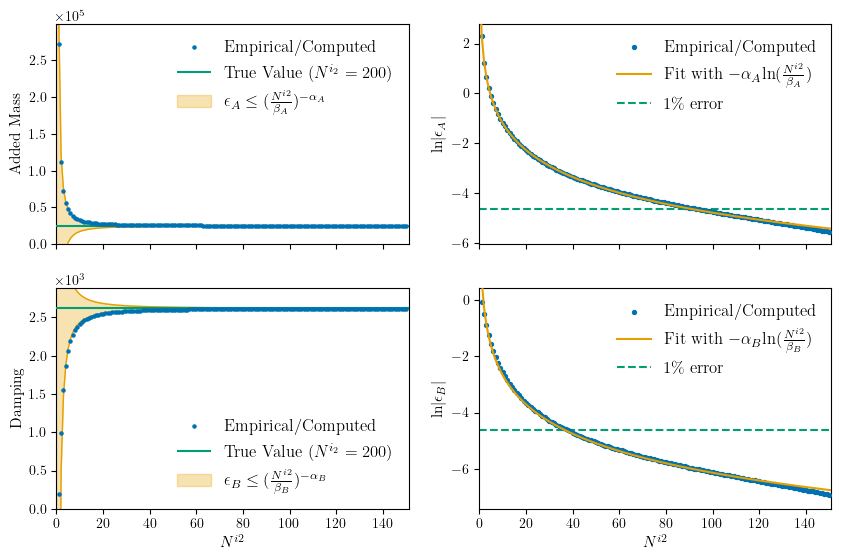

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(fig_w * 2.5, fig_h * 0.7), sharex='col')
for ax in axs.flat: format_ax(ax)
alpha, beta = plot_type_2(axs[0][1], data1, m0, "am")
plot_type_1(axs[0][0], data1, m0, "am", alpha, beta, loc = "upper right")
alpha, beta = plot_type_2(axs[1][1], data1, m0, "dp")
plot_type_1(axs[1][0], data1, m0, "dp", alpha, beta, loc = "lower right")
for ax in [axs[1][0], axs[1][1]]:
    ax.set_xlabel(rf"$N^{{i2}}$", fontsize = lab_fs)
fig.savefig(fig_path_1_str, format='pdf', dpi=300, bbox_inches='tight')

In [6]:
data2 = open_pkl_file(data_1_str)[1]
_ = generate_log_data(data2)
sub_data2 = [data2[i] for i in range(0, 29, 7)]

In [7]:
hmdr_f = lambda cf: (cf["h"]-cf["d"][1])/(cf["a"][1]-cf["a"][0])

def get_alpha_beta(xs, ys, cf, parameter_formula):
  if parameter_formula is None:
    popt, pcov = curve_fit(lambda x, a1, a2 : (- a1 * np.log(x/a2)), xs, ys, p0=(1, 1))
    return popt
  else:
    return parameter_formula(cf)

def plot_type_3(ax, cfs, hydro, parameter_formula = None):
  if hydro == "am": subscript = "A"
  elif hydro == "dp": subscript = "B"

  if parameter_formula is None:
    label = (rf"$\alpha_{subscript}, \beta_{subscript}$ fit" "\n" "directly to" "\n" "scattered data")
  else:
    label = (rf"$\alpha_{subscript}, \beta_{subscript}$ from" "\n" "curves in (b) and (c)")

  nmk_big = len(cfs[0][cfs[0]["m0s"][0]][hydro + "s"])
  xs = list(range(1, nmk_big + 1))
  sub_xs = list(range(1, nmk_big + 1, 5))
  xmin, xmax = 0, len(xs) + 1
  xs2 = [0.05] + xs + [xmax]
  colormap, norm = "viridis", Normalize(vmin = hmdr_f(cfs[0]), vmax = hmdr_f(cfs[-1]))
  cf_colors = color_by_f_value(wrap_m0(hmdr_f), cfs, cmap = colormap)
  all_ys, alphas, betas = [], [], []
  for i in range(len(cfs)):
    cf = cfs[i]
    m0 = cf["m0s"][0]
    true_val = cf[m0][hydro]
    ys = [np.log(np.abs((entry - true_val)/true_val)) for entry in cf[m0][hydro + "s"]]
    sub_ys = [ys[i] for i in range(0, nmk_big, 5)]
    all_ys.append(ys)
    alpha, beta = get_alpha_beta(xs, ys, cf, parameter_formula)
    alphas.append(alpha)
    betas.append(beta)
    ys2 = [- alpha * np.log(x/beta) for x in xs2]

    ax.scatter(sub_xs, sub_ys, c = cf_colors[i], s = 11, zorder = 3)
    ax.plot(xs2, ys2, color = cf_colors[i], linestyle = "-", zorder = 5)

  every_y_lst = [entry for ys in all_ys for entry in ys]
  ymin, ymax = min(every_y_lst) - 0.5, max(every_y_lst) + 0.5
  ax.plot([-1], [0], color = colors.black, label = label) # Out of view
  ax.legend(loc='upper right', fontsize=leg_fs * 0.9, frameon=False)
  ax.set_xlim([xmin, xmax])
  ax.set_ylim([ymin, ymax])
  ax.set_ylabel(rf"$\mathrm{{ln}}|\epsilon_{subscript}|$", fontsize = lab_fs)
  ax.set_xlabel(rf"$N^{{i_2}}$", fontsize = lab_fs)
  ax.figure.colorbar(ScalarMappable(cmap=colormap, norm=norm), ax=ax1, location='top', label = r"$\frac{h-d_2}{a_1-a_0}$", pad=0.02)
  return alphas, betas, colormap, norm

def plot_type_4(ax, cfs, hydro, parameters, formula, param_name, label, colormap = "viridis"):
  if hydro == "am": subscript = "A"
  elif hydro == "dp": subscript = "B"
  hmdrs = [hmdr_f(cf) for cf in cfs]
  xmin, xmax = 0, max(hmdrs) + 3
  cf_colors = color_by_f_value(wrap_m0(hmdr_f), cfs, cmap = colormap)
  ax.scatter(hmdrs, parameters, c= cf_colors, zorder = 5)
  fit_params, _ = curve_fit(formula, hmdrs, parameters)
  curve_xs = np.linspace(xmin, xmax, 100)
  curve_ys = [formula(hmdr, *fit_params) for hmdr in curve_xs]
  ax.plot(curve_xs, curve_ys, label = label, color = colors.red)
  if param_name == "alpha":
    ymin, ymax = 0.99 * min(parameters), 1.015 * max(parameters)
  elif param_name == "beta":
    ymin, ymax = 0, 1.1 * max(parameters)
  ax.set_xlim([xmin, xmax])
  ax.set_ylim([ymin, ymax])
  ax.legend(loc='upper left', fontsize=leg_fs * 0.9, frameon=False)
  ax.set_ylabel(rf"$\{param_name}_{subscript}$", fontsize = lab_fs)


In [8]:
def add_box(ax, lower_left, width, height, text = None, edgecolor = "black"):
    box = FancyBboxPatch(lower_left, width, height,
                        boxstyle="square,pad=0.02", linewidth=1.5,
                        facecolor="white", edgecolor=edgecolor)
    ax.add_patch(box)
    if text is not None:
        ax.text(lower_left[0] + width / 2, lower_left[1] + height - 0.005, text,
                ha="center", va="top", fontsize=lab_fs, weight="bold")
    return box

def add_embedded_ax(fig, box, left = 0.06, right = 0.06, top = 0.12, bottom = 0.12):
    x, y = box.get_x(), box.get_y()
    width, height = box.get_width(), box.get_height()
    ax = fig.add_axes([x + left * width,
                       y + bottom * height,
                       (1-left-right) * width,
                       (1-top-bottom) * height])
    return ax

def add_arrow(ax, start, end, color = colors.red):
    ax.annotate("", xy=end, xytext=start,
                arrowprops=dict(arrowstyle="-|>,head_length=1.0,head_width=0.45",
                                lw=5, shrinkA=11, shrinkB=9, color = color,
                                mutation_scale=10, capstyle="butt", joinstyle="miter"))

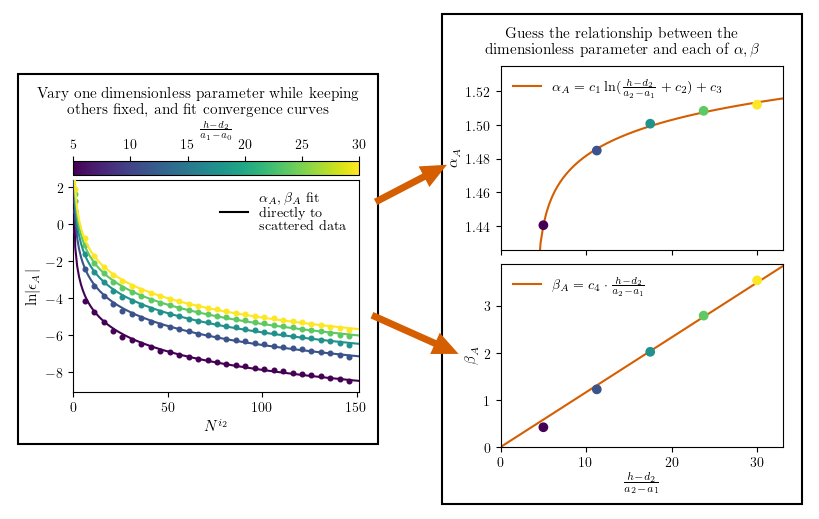

In [9]:
fig = plt.figure(figsize=(8, 5))
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

f1 = lambda hmdr, a1, a2, a3 : a1 * np.log(hmdr - a2) + a3
f2 = lambda hmdr, a1 : a1 * hmdr

double_top, double_bottom, separation = 0.09, 0.1, 0.03
each_height = (1 - (double_top + double_bottom + separation))/2

box1 = add_box(ax, (0.03, 0.15), 0.41, 0.7, text = "Vary one dimensionless parameter while keeping\nothers fixed, and fit convergence curves")
box2 = add_box(ax, (0.56, 0.03), 0.41, 0.94, text = ("Guess the relationship between the\ndimensionless parameter and each of " r"$\alpha, \beta$"))
ax1 = add_embedded_ax(fig, box1, right = 0.01, left = 0.12, top = 0.15)
ax2 = add_embedded_ax(fig, box2, right = 0.01, left = 0.13, bottom = double_bottom + each_height + separation, top = double_top)
ax3 = add_embedded_ax(fig, box2, right = 0.01, left = 0.13, bottom = double_bottom, top = double_top + each_height + separation)
ax2.sharex(ax3)
ax2.tick_params(labelbottom=False)
for ax0 in [ax1, ax2, ax3]: format_ax(ax0)

alphas, betas, colormap, norm = plot_type_3(ax1, sub_data2, "am")
plot_type_4(ax2, sub_data2, "am", alphas, f1, "alpha", r"$\alpha_A = c_1 \ln(\frac{h-d_2}{a_2-a_1}+c_2) + c_3 $", colormap = "viridis")
plot_type_4(ax3, sub_data2, "am", betas, f2, "beta", r"$\beta_A = c_4 \cdot \frac{h-d_2}{a_2-a_1}$", colormap = "viridis")
ax3.set_xlabel(r"$\frac{h-d_2}{a_2-a_1}$", fontsize = lab_fs, labelpad = 2)

add_arrow(ax, (box1.get_x() + box1.get_width(), 0.6), (box2.get_x(), 0.7), color = colors.red)
add_arrow(ax, (box1.get_x() + box1.get_width() - 0.005, 0.4), (box2.get_x() + 0.015, 0.3), color = colors.red)
fig.savefig(fig_path_2_str, format='pdf', dpi=300, bbox_inches='tight')

In [10]:
# Import data for convergence study fitting and comparison.
random_data_1 = open_pkl_file(data_2_str)
random_data_2 = open_pkl_file(data_3_str)

def convert_to_typical(random_data, heave, region):
  def new_cf(cf):
    m0 = cf["m0s"][0]
    return {"h" : cf["h"],
            "d" : cf["d"],
            "a" : cf["a"],
            "m0s" : cf["m0s"],
            m0 : {"am" : cf[m0][heave]["am"],
                  "dp" : cf[m0][heave]["dp"],
                  "ams" : cf[m0][heave][region]["ams"],
                  "dps" : cf[m0][heave][region]["dps"]}}
  return [new_cf(cf) for cf in random_data]

def unshielded(cf):
  if len(cf["d"]) < 3: return True
  for i in range(2, len(cf["d"])):
    if (cf["h"] - cf["d"][i]) < (cf["h"] - cf["d"][1]): return False
  return True

def filter_unshielded(cfs):
  return [cf for cf in cfs if unshielded(cf)]

def filter_shielded(cfs):
  return [cf for cf in cfs if not unshielded(cf)]

test_set_00 = (filter_unshielded(convert_to_typical(random_data_1, 0, 0) + convert_to_typical(random_data_2, 0, 0)))
test_set_00s = (filter_shielded(convert_to_typical(random_data_1, 0, 0) + convert_to_typical(random_data_2, 0, 0)))
test_set_11 = (convert_to_typical(random_data_1, 1, 1))# + convert_to_typical(random_data_2, 1, 1) + convert_to_typical(random_data_2, 2, 2))
test_set_22 = (convert_to_typical(random_data_1, 2, 2))# + convert_to_typical(random_data_2, 3, 3))
test_set_ext = (convert_to_typical(random_data_1, 2, 3))# + convert_to_typical(random_data_2, 3, 4))

for test_set in [test_set_00, test_set_00s, test_set_11, test_set_22, test_set_ext]:
  generate_convergence_data(test_set, [0.01])
  _ = generate_log_data(test_set)

test_set_00 = filter_converged(test_set_00)
test_set_00s = filter_converged(test_set_00s)
test_set_11 = filter_converged(test_set_11)
test_set_22 = filter_converged(test_set_22)

all_cfs = [test_set_00, test_set_11, test_set_22, test_set_22]

In [11]:
# Define fitting functions
sigmoid = lambda a, b, c, x : (b/(1 + np.exp(-a*(x-1)))) + c
log_like = lambda a, b, c, x : a * np.log(x+c) + b
linear = lambda a, b, x : a * x + b

def inner_am_model():
  def model_vars(vars, a1, a2, b1, c1, c2, a51, a52, a53, a6):
    hmdr, right_ratio = vars
    alpha = log_like(a1, b1, c1, hmdr) * (right_ratio < 1) + log_like(a2, b1, c2, hmdr) * (right_ratio >= 1)
    beta = (sigmoid(a51, a52, a53, right_ratio) * (right_ratio < 1) + a6 * (right_ratio >= 1)) * hmdr
    return alpha, beta
  
  variables_used = ["(h-d)/radwidth", "(h-d_out)/(h-d)"]
  guess = (1.44, 1.44, 0.03, 1, 1, 0.2, 0.2, 0.2, 0.03)
  return model_vars, variables_used, guess

def middle_am_model():
  def model_vars(vars, a1, a2, a3, a4, b1, c1, a51, a52, a53, a6, a7, a8):
    hmdr, left_ratio, right_ratio = vars
    a0 = ((a1 * (right_ratio < 1) + a2 * (right_ratio >= 1)) * (left_ratio < 1)
          + (a3 * (right_ratio < 1) + a4 * (right_ratio >= 1)) * (left_ratio >= 1))
    alpha = log_like(a0, b1, c1, hmdr)
    beta1 = sigmoid(a51, a52, a53, right_ratio) * (right_ratio < 1) + a6 * (right_ratio >= 1)
    beta2 = a7 * (left_ratio < 1) + a8 * (left_ratio >= 1)
    return alpha, beta1 * beta2 * hmdr
  
  variables_used = ["(h-d)/radwidth", "(h-d_in)/(h-d)", "(h-d_out)/(h-d)"]
  guess = (0.023, 0.023, 0.023, 0.023, 1.44, 1,
           0.2, 0.2, 0.2, 0.03, 0.2, 0.03)
  return model_vars, variables_used, guess

def outer_am_model():
  def model_vars(vars, a1, b1, a2, b2, c2, b3, c3,
                 a4, b4, a5, b5, c5, a6, b6): # 14 variables
    hmdr, left_ratio, right_ratio, rad_to_center = vars
    alpha1 = a1 * (left_ratio < 1) + b1 * (left_ratio >= 1)
    alpha2 = log_like(a2, b2, c2, right_ratio)
    alpha = log_like(alpha1 * alpha2, b3, c3, hmdr)
    beta1 = a4 * (left_ratio < 1) + b4 * (left_ratio >= 1)
    beta2 = log_like(a5, b5, c5, right_ratio)
    beta3 = linear(a6, b6, rad_to_center)
    beta = beta1 * beta2 * beta3 * hmdr
    return alpha, beta
  
  variables_used = ["(h-d)/radwidth", "(h-d_in)/(h-d)", "h/(h-d)", "radwidth/dist_to_c"]
  guess = [1.7, 1.1, 1.3, 1.2, 1, 1.4, 1,
           0.2, 0.2, 1.5, 1.4, 1, 1.3, 1.2]
  return model_vars, variables_used, guess

def outer_dp_model(): # independent of left ratio, m0h dependencies linked
  def model_vars(vars, a1, b1, c1, b2, a3, b3, b4):
    hmdr, m0h, right_ratio = vars
    alpha = (log_like(a1, b1, c1, right_ratio)) * np.exp(-b2 * m0h) + 1
    beta = (np.exp(-b4 * right_ratio)) * (a3 * hmdr + b3) * ((m0h ** 0.5) * (m0h > 5) + m0h/(5**0.5) * (m0h <=5))
    return alpha, beta
  variables_used = ["(h-d)/radwidth", "m0h", "h/(h-d)"]
  guess = [0.5, 0.016, 0, 0.01, 0.09, 2, 0.1]
  return model_vars, variables_used, guess

model_packs = [variables_guess_variants(inner_am_model, "innermost"),
               variables_guess_variants(middle_am_model, "middle"),
               variables_guess_variants(outer_am_model, "outermost"),
               variables_guess_variants(outer_dp_model, "outermost")]

fit_keys = [("1", "added mass"),
            ("2", "added mass"),
            ("M", "added mass"),
            ("M", "damping")]

weighted_fitting_fcns = [fit_inner_model_weighted,
                         fit_middle_model_weighted,
                         fit_outer_model_weighted,
                         fit_outer_model_weighted]

hydros = ["am", "am", "am", "dp"]

In [12]:
# Fit
underweight = 1
params_list = []
for i in range(4):
  variables_used, guess, fit_model, cf_params_to_alpha_beta, err_from_nmk_model, nmk_from_err_model = model_packs[i]
  params, res = weighted_fitting_fcns[i](all_cfs[i], hydros[i], fit_model, guess, variables_used,  underweight = underweight)
  params_list.append([twenty_minimum(nmk_from_err_model), params])
  print("Finished a model.")

Finished a model.


Finished a model.


Finished a model.


Finished a model.


In [13]:
# Define plotting function.
def get_error(cf, m0, nmk, hydro):
  true_value = cf[m0][hydro]
  if nmk <= len(cf[m0][hydro + "s"]): # has already been computed
    val = cf[m0][hydro + "s"][nmk - 1]
  else:
   val = true_value * 1.0001 # placeholder to reduce excessive computation
  return (val - true_value)/true_value

def err_nmk_diff_vals(all_cfs, hydros, params_list): # 1% error assumed
  all_calculated_errs, all_calculated_nmk_diffs, sample_sizes = [], [], []
  for i in range(len(all_cfs)):
    sample_size = len(all_cfs[i])
    nmk_from_err_model, params = params_list[i]
    nmks = [math.ceil(nmk_from_err_model(0.01, cf, cf["m0s"][0], *params)) for cf in all_cfs[i]]
    errs = [np.abs(get_error(all_cfs[i][j], all_cfs[i][j]["m0s"][0], nmks[j], hydros[i])) for j in range(len(all_cfs[i]))]
    true_nmks = [cf[cf["m0s"][0]]["convergence point 0.01 " + hydros[i]] for cf in all_cfs[i]]
    nmk_diffs = [nmks[i] - true_nmks[i] for i in range(len(all_cfs[i]))]
    all_calculated_errs.append(errs)
    all_calculated_nmk_diffs.append(nmk_diffs)
    sample_sizes.append(sample_size)
  return all_calculated_errs, all_calculated_nmk_diffs, sample_sizes

def hydro_err_plot(all_cfs, hydros, params_list, fit_keys):
  fig, axs = plt.subplots(1, 2, figsize = (8, 5), sharey = "row")
  ax1, ax2 = axs
  all_calculated_errs, all_calculated_nmk_diffs, sample_sizes = err_nmk_diff_vals(all_cfs, hydros, params_list)
  labels = [(rf"Region $i_{{{fit_keys[i][0]}}}$" f"\n {fit_keys[i][1]}" f"\n (n = {sample_sizes[i]})") for i in range(len(fit_keys))]
  ax1.boxplot(all_calculated_errs[::-1], whis=(5, 95), vert=False, tick_labels = labels[::-1])
  ax2.boxplot(all_calculated_nmk_diffs[::-1], whis=(5, 95), vert=False, tick_labels = labels[::-1])
  for ax in axs: ax.grid(True, axis='x', alpha = 0.5)
  ax1.set_xlabel(r"$|$Relative error at predicted $N^{i_m}|$" "\nfor " r"$1\%$ Convergence")
  ax2.set_xlabel(r"Difference between predicted and actual $N^{i_m}$" "\nfor " r"$1\%$ Convergence")
  fig.savefig(fig_path_3_str, format='pdf', dpi=300, bbox_inches='tight')


In [14]:
# Adds shielded data set, but to be fit with curve for unshielded.
# all_cfs = [test_set_00, test_set_00s, test_set_11, test_set_22, test_set_22]
# fit_keys = [("1", "added mass"),
#             ("1", "added mass \n(shielded)"),
#             ("2", "added mass"),
#             ("M", "added mass"),
#             ("M", "damping")]
# hydros = ["am", "am", "am", "am", "dp"]
# params_list = [params_list[0]] + [params_list[0]] + params_list[1:]

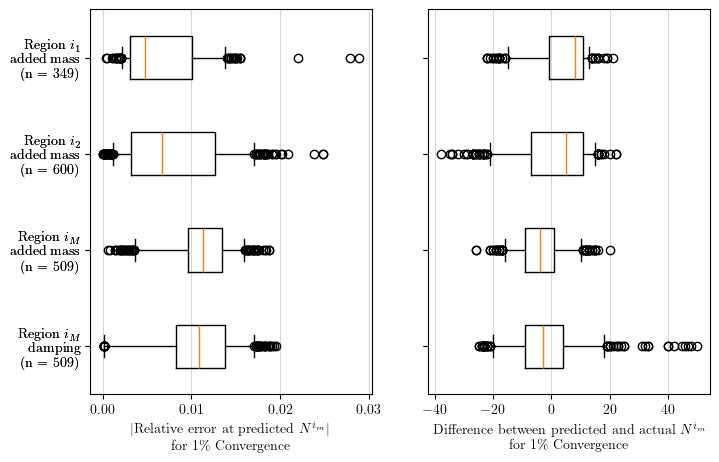

In [15]:
hydro_err_plot(all_cfs, hydros, params_list, fit_keys)